# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw01/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 1 ([конспект](../../lectures/lecture01/lecture01.md), [демо](../../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)–(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это очевидно). По 1 баллу за пункт.

**(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**(а)**

**Ответ.** Пусть $p=(1,2,3)^\top$. Переменная $x=(x_1,x_2,x_3)^\top\in\mathbb R^3$. Стандартная форма:

$$\min_{x\in\mathbb R^3} f(x)=\frac12\lVert x-p\rVert_2^2,\qquad
g(x)=\begin{pmatrix}x_1+x_2+x_3-1\\x_1-x_3\end{pmatrix}=0,$$

а неравенств нет ($h$ — пустой вектор). Это **QP с ограничениями**. Задача выпуклая: целевая функция строго выпукла ($\nabla^2f=I\succ0$), а равенства аффинны. Поэтому допустимый минимум единственен.

In [2]:
p = np.array([1.0, 2.0, 3.0])
C = np.array([[1.0, 1.0, 1.0],
              [1.0, 0.0, -1.0]])
d = np.array([1.0, 0.0])

# Проекция p на множество Cx=d.
x_nearest = p - C.T @ np.linalg.solve(C @ C.T, C @ p - d)
print("Ближайшая точка:", x_nearest)
print("Проверка равенств Cx-d:", C @ x_nearest - d)

Ближайшая точка: [0.33333333 0.33333333 0.33333333]
Проверка равенств Cx-d: [-4.44089210e-16  2.22044605e-16]


**(б)**

**Ответ.** Переменная $x=(x_1,\ldots,x_n)^\top\in\mathbb R^n$ — количества продуктов. Тогда

$$\min_x f(x)=c^\top x,\qquad g(x)\text{ отсутствует},\qquad
h(x)=\begin{pmatrix}Ax-b\\x\end{pmatrix}\geq0.$$

Это **задача линейного программирования**, поскольку цель и все ограничения аффинны. Задача выпуклая: допустимое множество является пересечением полупространств, а линейная функция одновременно выпукла и вогнута.

**(в)**

**Ответ.** Обозначим через $u,v\geq0$ половины сторон прямоугольника; его вершины имеют координаты $(\pm u,\pm v)$. Можно разрешить вершинам лежать внутри круга: максимум всё равно достигается на его границе. При $x=(u,v)^\top\in\mathbb R^2$ получаем

$$\min_x f(x)=-4uv,\qquad g(x)\text{ отсутствует},\qquad
h(x)=\begin{pmatrix}1-u^2-v^2\\u\\v\end{pmatrix}\geq0.$$

Это **QCQP с ограничениями**: цель и первое ограничение квадратичны. Задача невыпуклая, потому что гессиан $f$ равен $\begin{pmatrix}0&-4\\-4&0\end{pmatrix}$ и имеет собственные значения $\pm4$, то есть $f$ не выпукла. (Допустимое множество при выбранной записи выпукло.) Из $u^2+v^2\geq2uv$ следует $4uv\leq2$; равенство достигается при $u=v=1/\sqrt2$, поэтому максимальная площадь равна $2$.

**(г)**

**Ответ.** Переменная $x=(x_1,x_2,x_3)^\top\in\mathbb R^3$, где $x_1$ — амплитуда, $x_2$ — частота, $x_3$ — фаза. Стандартная форма:

$$\min_{x\in\mathbb R^3} f(x)=\sum_{i=1}^{N}\left[x_1\sin(x_2t_i+x_3)-y_i\right]^2,$$

причём $g$ и $h$ отсутствуют. Это **NLP без ограничений** (нелинейный МНК). В общем случае задача невыпуклая: параметры $x_2$ и $x_3$ входят внутрь периодической функции, поэтому у цели могут быть несколько локальных минимумов.

**(д, бонус)**

**Ответ.** Введём эпиграфическую переменную $\tau$ и объединим переменные в $z=(x,\tau)\in\mathbb R^{n+1}$. Тогда эквивалентная гладкая задача имеет вид

$$\min_{x,\tau}\;\tau$$

при ограничениях для всех $i$

$$\tau-(a_i^\top x-b_i)\geq0,\qquad
\tau+(a_i^\top x-b_i)\geq0.$$

То есть $g$ отсутствует, а $h(z)$ состоит из перечисленных $2m$ аффинных функций. Условие $\tau\geq0$ следует из этих неравенств (и его можно добавить явно). Это **LP с ограничениями**, следовательно, выпуклая задача.

## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ — логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

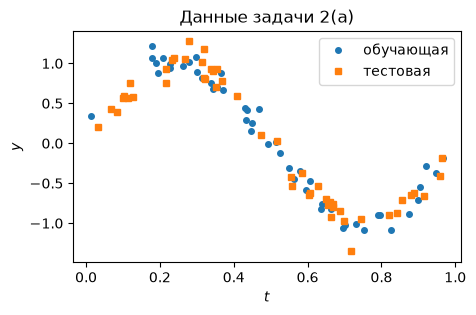

In [3]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)")
plt.show()

Минимальная тестовая MSE при d=5: 0.025973


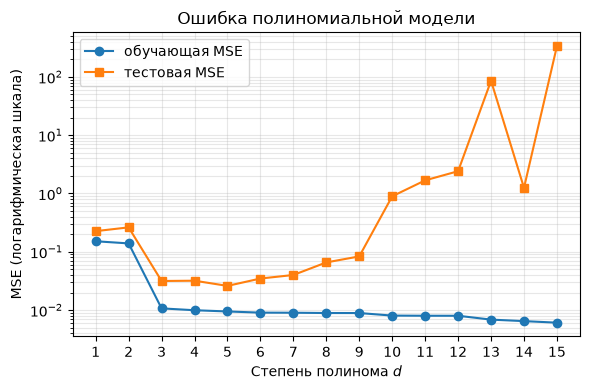

In [ ]:
degrees = np.arange(1, 16)
train_mse = []
test_mse = []

for degree in degrees:
    A_train = np.vander(t_train, degree + 1, increasing=True)
    coefficients, *_ = np.linalg.lstsq(A_train, y_train, rcond=None)
    A_test = np.vander(t_test, degree + 1, increasing=True)

    train_mse.append(np.mean((A_train @ coefficients - y_train) ** 2))
    test_mse.append(np.mean((A_test @ coefficients - y_test) ** 2))

best_degree = degrees[np.argmin(test_mse)]
print(f"Минимальная тестовая MSE при d={best_degree}: {min(test_mse):.6f}")

plt.figure(figsize=(6, 4))
plt.semilogy(degrees, train_mse, "o-", label="обучающая MSE")
plt.semilogy(degrees, test_mse, "s-", label="тестовая MSE")
plt.xticks(degrees)
plt.xlabel("Степень полинома d")
plt.ylabel("MSE (логарифмическая шкала)")
plt.title("Ошибка полиномиальной модели")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Ответ.** Обучающая MSE не возрастает: пространство полиномов степени не выше $d$ вложено в пространство для степени $d+1$, поэтому новый коэффициент всегда можно положить равным нулю, а метод МНК выбирает не худший вариант. Тестовая ошибка не обязана быть монотонной: сначала увеличение степени уменьшает смещение модели, но затем полином начинает подгонять шум обучающей выборки (и становится численно неустойчивее), поэтому ошибка на новых данных растёт. Для данных с заданным seed её минимум достигается при $d=5$.

**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [5]:
c = np.array([2.0, 3.0, 1.5, 4.0])                # цены продуктов
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])                 # содержание вещества i в продукте j
b = np.array([10.0, 8.0, 12.0])                     # минимальные требования

In [ ]:
def solve_diet(requirements, tol=1e-9):
    result = linprog(c, A_ub=-A, b_ub=-requirements,
                     bounds=(0, None), method="highs")

    nutrient_slack = A @ result.x - requirements
    active_nutrients = np.flatnonzero(np.abs(nutrient_slack) <= tol) + 1
    active_nonnegativity = np.flatnonzero(np.abs(result.x) <= tol) + 1
    return result, nutrient_slack, active_nutrients, active_nonnegativity

b_new = b.copy()
b_new[0] += 1

for label, requirements in [("Исходная задача", b),
                            ("После увеличения b₁", b_new)]:
    result, slack, active_A, active_x = solve_diet(requirements)
    print(label)
    print("  x =", np.round(result.x, 10))
    print(f"  стоимость = {result.fun:.10g}")
    print("  невязки Ax-b =", np.round(slack, 10))
    print("  активные ограничения Ax≥b:", active_A.tolist())
    print("  активные ограничения x≥0:", active_x.tolist())

Исходная задача
  x = [ 2.  4. -0.  0.]
  стоимость = 16
  невязки Ax-b = [0. 0. 0.]
  активные ограничения Ax≥b: [1, 2, 3]
  активные ограничения x≥0: [3, 4]
После увеличения b₁
  x = [1.88888889 3.55555556 0.         0.66666667]
  стоимость = 17.11111111
  невязки Ax-b = [0. 0. 0.]
  активные ограничения Ax≥b: [1, 2, 3]
  активные ограничения x≥0: [3]


**Ответ.** В исходной задаче

$$x^*=(2,4,0,0)^\top,\qquad c^\top x^*=16.$$

Все три ограничения на питательные вещества активны: $Ax^*-b=(0,0,0)^\top$. Среди условий неотрицательности активны $x_3\geq0$ и $x_4\geq0$.

После замены $b_1=10$ на $b_1=11$ получаем

$$\widetilde x^*=\left(\frac{17}{9},\frac{32}{9},0,\frac23\right)^\top,\qquad
c^\top\widetilde x^*=\frac{154}{9}\approx17.1111.$$

Стоимость выросла на $10/9\approx1.1111$, и количества продуктов 1, 2 и 4 изменились. Все три ограничения $A\widetilde x\geq\widetilde b$ остались активными, но среди ограничений неотрицательности теперь активно только $x_3\geq0$: продукт 4 вошёл в оптимальный рацион.